## Buffers & Spatial Intersections

**Data:** CAL FIRE historical fire perimeters (`fire24_1.gdb`, 2010–2025) + US Census CA place boundaries (`tl_2023_06_place.shp`, 1,618 places)

**What this notebook does:**
- Expands each fire perimeter by a 10 km buffer zone to approximate the area of immediate threat
- Performs a spatial join between buffered fire areas and CA populated place boundaries to identify at-risk communities
- Ranks fires by the number of distinct places their buffer overlaps — the **Dixie Fire (2021)** tops the list at 45 communities
- Produces a focused map of the Dixie Fire showing the burn perimeter, buffer zone, and surrounding place boundaries

**Key methods:** `.buffer()`, `gpd.sjoin()`, `.to_crs()`, `contextily` basemaps, `total_bounds` for map zoom

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

In [2]:
# Load fire perimeters
gdf = gpd.read_file("../data/raw/fire24_1.gdb", layer="firep24_1")
gdf_recent = gdf[gdf['YEAR_'] >= 2010]
print(gdf.crs)

f:\GeoPandas Projects\ca-wildfire-project\venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


EPSG:3310


## Buffer Fire Perimeters

In [3]:
gdf_buffered = gdf_recent.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(10000)  # Buffer by 10 km

In [6]:
print(gdf_buffered)

       YEAR_ STATE AGENCY UNIT_ID  FIRE_NAME   INC_NUM  \
0     2025.0    CA    CDF     LDF  PALISADES  00000738   
1     2025.0    CA    CDF     LAC      EATON  00009087   
2     2025.0    CA    CDF     ANF     HUGHES  00250270   
3     2025.0    CA    CCO     VNC    KENNETH  00003155   
4     2025.0    CA    CDF     LDF      HURST  00003294   
...      ...   ...    ...     ...        ...       ...   
5456  2010.0    CA    CDF     SKU    EASTMAN  00005434   
5457  2010.0    CA    CDF     SKU     HOLLOW  00005373   
5458  2010.0    CA    CCO     LAC      OLIVE    NPS499   
5459  2010.0    CA    CDF     SKU     EMPIRE  00005404   
5460  2010.0    CA    CDF     SKU    WHISKEY  00004299   

                                     IRWINID                ALARM_DATE  \
0     {A7EA5D21-F882-44B8-BF64-44AB11059DC1} 2025-01-07 00:00:00+00:00   
1     {72660ADC-B5EF-4D96-A33F-B4EA3740A4E3} 2025-01-08 00:00:00+00:00   
2     {994072D2-E154-434A-BB95-6F6C94C40829} 2025-01-22 00:00:00+00:00   
3     {

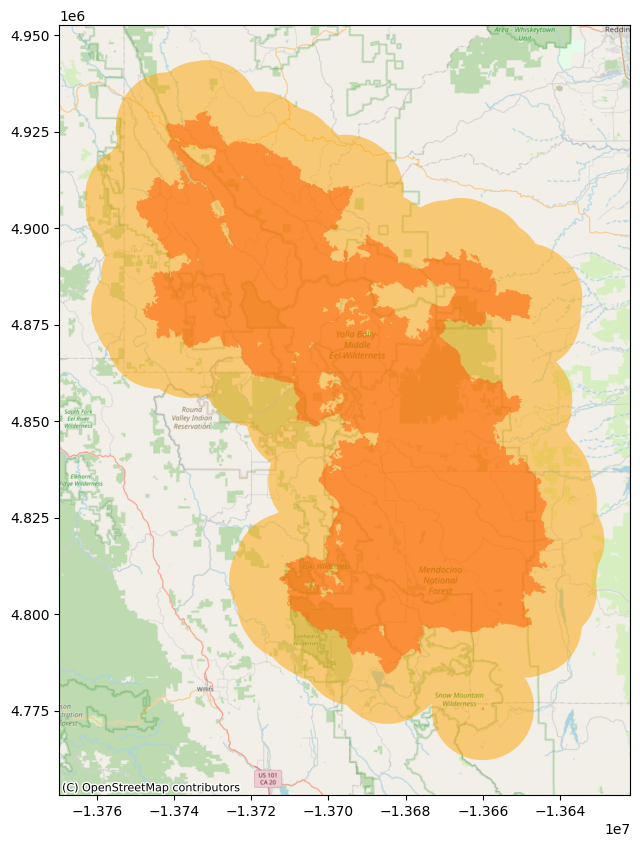

In [22]:
# Identify largest fire by area with buffer overlay
gdf_buffered_web = gdf_buffered.to_crs(epsg=3857)
gdf_recent_web = gdf_recent.to_crs(epsg=3857)
fire_idx = gdf_recent['GIS_ACRES'].idxmax()
gdf_recent_web.loc[[fire_idx]]

# Plot largest fire with buffer and basemap
figure, ax = plt.subplots(figsize=(10, 10))
gdf_recent_web.loc[[fire_idx]].plot(ax=ax, color='red', alpha=0.5)
gdf_buffered_web.loc[[fire_idx]].plot(ax=ax, color='orange', alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)



## Identify Neighborhood Boundaries & Intersect Buffered Fires with Populated Places

In [ ]:
# Loading boundary data, converting to same CRS
ca_place = gpd.read_file("../data/raw/tl_2023_06_place.shp")
print(ca_place.crs)
ca_place_3310 = ca_place.to_crs(epsg=3310)
print(ca_place_3310.crs)
print(ca_place_3310.shape)


EPSG:4269
EPSG:3310
(1618, 17)


In [38]:
print(gdf_buffered.crs)

EPSG:3857


In [46]:
#convert gdf_buffered to same CRS as ca_place_3310
gdf_buffered_3310 = gdf_buffered.to_crs(epsg=3310)
print(gdf_buffered_3310.crs)

# Spatial join to find which fires intersect with place boundaries
places_at_risk = gpd.sjoin(ca_place_3310, gdf_buffered_3310[['FIRE_NAME', 'YEAR_', 'GIS_ACRES', 'geometry']], how='inner', predicate='intersects')
print(places_at_risk[['NAME', 'FIRE_NAME', 'YEAR_', 'GIS_ACRES']])

EPSG:3310
                           NAME             FIRE_NAME   YEAR_     GIS_ACRES
0                  San Fernando               LA TUNA  2017.0   7051.351074
0                  San Fernando              DOMINICA  2017.0     11.154638
0                  San Fernando             WHEATLAND  2016.0    155.912994
0                  San Fernando                 KAGEL  2016.0     61.806499
0                  San Fernando                 CREEK  2017.0  15619.146484
...                         ...                   ...     ...           ...
1615            Yosemite Valley  PORCUPINE CAMPGROUND  2017.0      0.079341
1615            Yosemite Valley             PORCUPINE  2017.0     10.518025
1615            Yosemite Valley            CAMPGROUND  2014.0      0.100800
1615            Yosemite Valley               BLUEJAY  2020.0   6922.013672
1617  Woodville Farm Labor Camp                  MAIN  2021.0    378.472443

[18619 rows x 4 columns]


In [63]:
#identify number of unique locations at risk
places_at_risk['NAME'].nunique()

# Identify the top 5 most threatening fires
places_at_risk.groupby(['FIRE_NAME', 'YEAR_'])['NAME'].nunique().nlargest(5)

FIRE_NAME  YEAR_ 
DIXIE      2021.0    45
           2012.0    40
SYCAMORE   2022.0    40
CANYON     2017.0    39
           2024.0    38
Name: NAME, dtype: int64

In [ ]:
# Find top 3 most threatening fires and their buffers
# Filter out records with empty fire names

places_clean = places_at_risk[places_at_risk['FIRE_NAME'].str.strip() != '']
top_fires = places_clean.groupby(['FIRE_NAME', 'YEAR_'])

# print(top_fires['NAME'].nunique().nlargest(3))

top_fire_pairs = top_fires['NAME'].nunique().nlargest(3).index.tolist()
print(top_fire_pairs)

#identify the fire names for the top 3 most threatening fires and filter gdf_buffered_3310 to only include those fires
top3_names = [pair[0] for pair in top_fire_pairs]
top3_buffers = gdf_buffered_3310[gdf_buffered_3310['FIRE_NAME'].isin(top3_names)]


[('DIXIE', 2021.0), ('SYCAMORE', 2022.0), ('CANYON', 2017.0)]


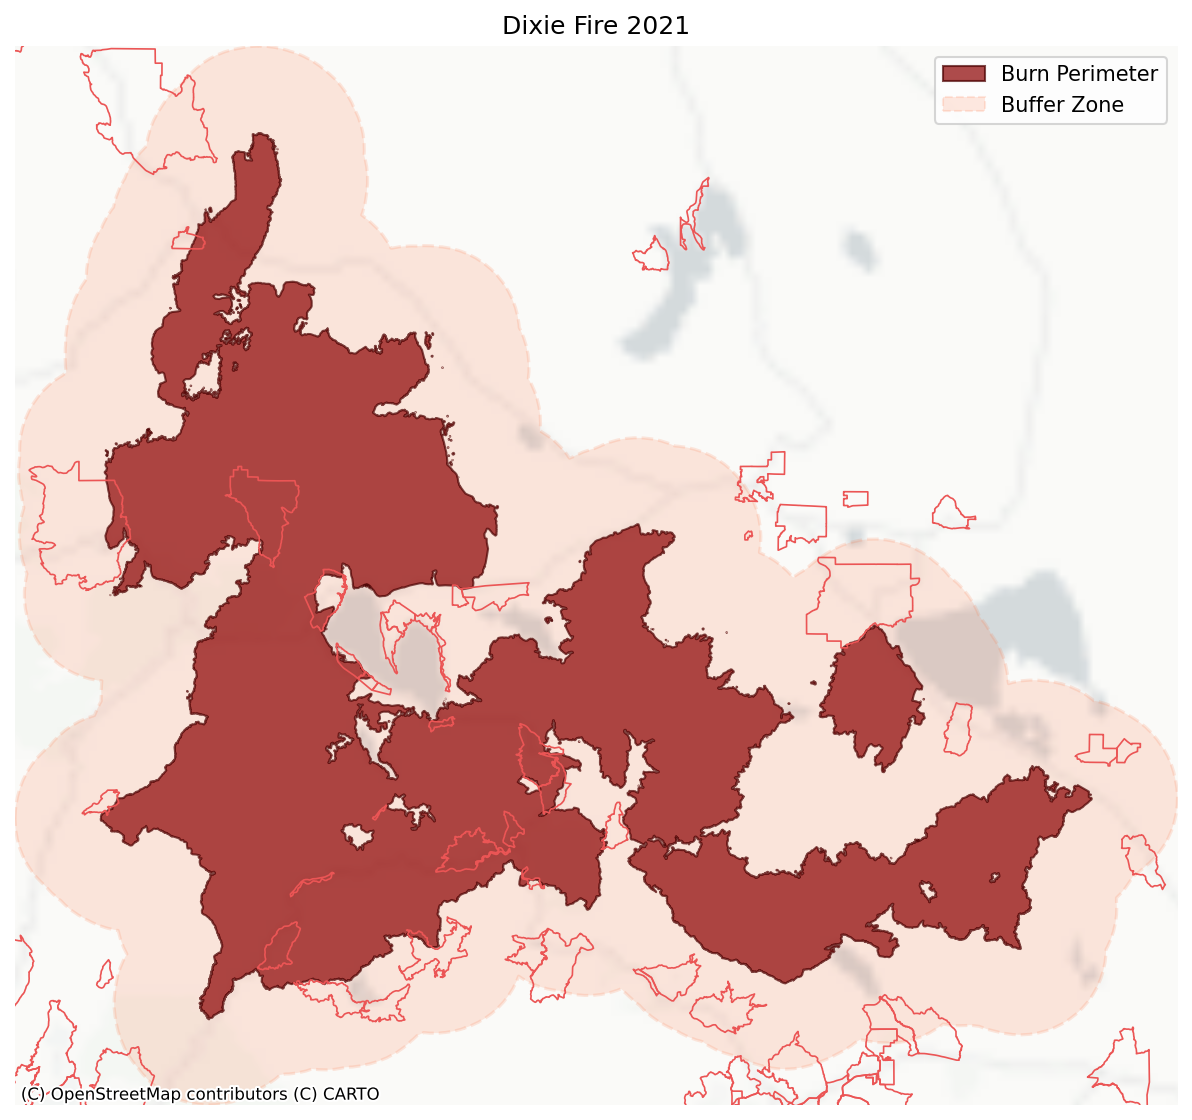

In [138]:
#Plot the most threatening singular fire with its buffer zone as well as surrounding neighborhoods
from matplotlib.patches import Patch

dixie_buffer_web = gdf_buffered_3310[(gdf_buffered_3310['FIRE_NAME'] == 'DIXIE') & (gdf_buffered_3310['YEAR_'] == 2021.0)].to_crs(epsg=3857)
dixie_fire_web = gdf_recent[(gdf_recent['FIRE_NAME'] == 'DIXIE') & (gdf_recent['YEAR_'] == 2021.0)].to_crs(epsg=3857)
ca_place_web = ca_place_3310.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
dixie_buffer_web.plot(ax=ax, facecolor='#FF6B35', alpha=0.15, edgecolor='#FF6B35', linestyle='--', linewidth=1.5)
dixie_fire_web.plot(ax=ax, facecolor='#8B0000', alpha=0.7, edgecolor='#4A0000', linewidth=1)
ca_place_web.plot(ax=ax, facecolor='none', edgecolor='#EB5555', linewidth=0.8)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.axis('off')
plt.title('Dixie Fire 2021')

# Zoom into Dixie fire area
ax.set_xlim(dixie_buffer_web.total_bounds[0], dixie_buffer_web.total_bounds[2])
ax.set_ylim(dixie_buffer_web.total_bounds[1], dixie_buffer_web.total_bounds[3])

# Add legend
legend_elements = [
    Patch(facecolor='#8B0000', alpha=0.7, edgecolor='#4A0000', label='Burn Perimeter'),
    Patch(facecolor='#FF6B35', alpha=0.15, edgecolor='#FF6B35', linestyle='--', label='Buffer Zone')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.show()